# U-Net Architecture Comparison

Trains five configurations on the same data split, in a cumulative progression:

| Config | Loss | Residual | Dropout |
|---|---|---|---|
| `BCEDice` | BCE + Dice | ✗ | ✗ |
| `FocalDice` | Focal + Dice | ✗ | ✗ |
| `+ residual` | Focal + Dice | ✓ | ✗ |
| `+ dropout` | Focal + Dice | ✗ | ✓ |
| `+ both` | Focal + Dice | ✓ | ✓ |

**Quick smoke-test**: `MAX_TILES = 500`, `MAX_EPOCHS = 3`  
**Real comparison**: `MAX_TILES = None`, `MAX_EPOCHS = 20`

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import time
from collections import OrderedDict
from pathlib import Path
import sys, os

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from torch import nn
from torch.utils.data import Dataset, DataLoader

from lunar_segmentation.lunar_segmentation.models.unet import SmallUNet
from lunar_segmentation.lunar_segmentation.training.trainer import (
    Trainer, FocalDiceLoss, BCEDiceLoss, multilabel_metrics
)
from lunar_segmentation.lunar_segmentation.data.preprocessing import CLASS_NAMES

print("Imports OK")

Imports OK


## 1. Experiment Controls

Change only this cell to adjust the experiment scope.

In [2]:
# ─── LOCAL vs CLOUDVENETO ─────────────────────────────────────────────────────
# Smoke test:        MAX_TILES =  500,  MAX_EPOCHS =  3   → ~10 min
# Quick comparison:  MAX_TILES = 2000,  MAX_EPOCHS = 10   → ~2.5 h
# Overnight local:   MAX_TILES = 4000,  MAX_EPOCHS = 20   → ~9 h
# CloudVeneto (GPU): MAX_TILES = None,  MAX_EPOCHS = 30   → full run
# ──────────────────────────────────────────────────────────────────────────────
MAX_TILES  = 4000   # int → first N tiles; None → full 15 931-tile dataset
MAX_EPOCHS = 20     # 3–5 for a quick smoke-test; 30 for CloudVeneto
BATCH_SIZE = 16
VAL_SPLIT  = 0.2    # fraction held out for validation (same split for all models)

# ─── LOSS ─────────────────────────────────────────────────────────────────────
LR            = 1e-3
CLASS_WEIGHTS = torch.tensor([1.0, 4.0, 5.0, 5.0, 5.0, 5.0, 5.0])
# ──────────────────────────────────────────────────────────────────────────────

BASE_DIR   = Path().resolve().parents[1] / "data" / "MR"
INDEX_PATH = BASE_DIR / "tiles" / "index.csv"
CKPT_DIR   = BASE_DIR / "results" / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Device     : {DEVICE}")
print(f"MAX_TILES  : {MAX_TILES}")
print(f"MAX_EPOCHS : {MAX_EPOCHS}")
print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"CKPT_DIR   : {CKPT_DIR}")

Device     : mps
MAX_TILES  : 4000
MAX_EPOCHS : 20
BATCH_SIZE : 16
CKPT_DIR   : /Users/giancarloventurato/Desktop/Astrophysics/Computational-Physics-2026/data/MR/results/checkpoints


## 2. Data

In [3]:
df = pd.read_csv(INDEX_PATH)
# Resolve relative paths to absolute
df["tile_path"] = df["tile_path"].apply(lambda p: str(BASE_DIR / p))

if MAX_TILES is not None:
    df = df.iloc[:MAX_TILES].reset_index(drop=True)

print(f"Using {len(df)} tiles from {df.aoi.nunique()} AOI(s)")

# Load all tiles into RAM once — shared across all model runs
print(f"Loading {len(df)} tiles into RAM…", flush=True)
_tiles = []
for _, row in df.iterrows():
    data = np.load(row["tile_path"])
    _tiles.append((data["image"].astype(np.float32),
                   data["mask"].astype(np.float32)))
print("Done.")

# Train / val split (fixed seed → same for every model)
rng     = np.random.default_rng(42)
idx     = rng.permutation(len(_tiles))
n_val   = max(1, int(len(idx) * VAL_SPLIT))
val_idx, train_idx = idx[:n_val], idx[n_val:]
print(f"Train: {len(train_idx)}  Val: {len(val_idx)}")

Using 4000 tiles from 1 AOI(s)
Loading 4000 tiles into RAM…
Done.
Train: 3200  Val: 800


In [4]:
class _TileDataset(Dataset):
    """Thin wrapper around a pre-loaded list of (image, mask) arrays."""
    def __init__(self, tiles, indices, augment=False):
        self.tiles   = tiles
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, mask = self.tiles[self.indices[i]]
        img, mask = img.copy(), mask.copy()
        if self.augment:
            # horizontal flip
            if np.random.random() < 0.5:
                img  = img[:,  :, ::-1].copy()
                mask = mask[:, :, ::-1].copy()
            # vertical flip
            if np.random.random() < 0.5:
                img  = img[:,  ::-1, :].copy()
                mask = mask[:, ::-1, :].copy()
            # 90 / 180 / 270 degree rotation — craters are rotationally symmetric
            k = np.random.randint(0, 4)
            if k:
                img  = np.rot90(img,  k=k, axes=(1, 2)).copy()
                mask = np.rot90(mask, k=k, axes=(1, 2)).copy()
        return torch.from_numpy(img), torch.from_numpy(mask)

train_ds = _TileDataset(_tiles, train_idx, augment=True)
val_ds   = _TileDataset(_tiles, val_idx,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Loaders ready  ({len(train_loader)} train batches, {len(val_loader)} val batches)")

Loaders ready  (200 train batches, 50 val batches)


## 3. Model Configurations

In [5]:
# Each entry: (display_name, arch_kwargs, loss_tag)
# loss_tag "bce_dice"   → BCEDiceLoss  (no class weights)
# loss_tag "focal_dice" → FocalDiceLoss(gamma=2, alpha=0.25, class_weights)
CONFIGS = OrderedDict([
    ("BCEDice",      dict(use_residual=False, dropout=0.0, loss="bce_dice")),
    ("FocalDice",    dict(use_residual=False, dropout=0.0, loss="focal_dice")),
    ("+ residual",   dict(use_residual=True,  dropout=0.0, loss="focal_dice")),
    ("+ dropout",    dict(use_residual=False, dropout=0.3, loss="focal_dice")),
    ("+ both",       dict(use_residual=True,  dropout=0.3, loss="focal_dice")),
])

def make_criterion(loss_tag):
    if loss_tag == "bce_dice":
        return BCEDiceLoss()
    return FocalDiceLoss(gamma=2.0, alpha=0.25, class_weights=CLASS_WEIGHTS)

# Architecture + loss summary
print(f"{'Config':<14} {'Loss':<12} {'Params':>10}  Notes")
print("-" * 55)
for name, cfg in CONFIGS.items():
    arch = {k: v for k, v in cfg.items() if k != "loss"}
    m    = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES), **arch)
    notes = ("residual " if arch["use_residual"] else "") +             (f"dropout={arch['dropout']}" if arch["dropout"] > 0 else "")
    print(f"{name:<14} {cfg['loss']:<12} {m.count_parameters():>10,}  {notes or '—'}")

Config         Loss             Params  Notes
-------------------------------------------------------
BCEDice        bce_dice      1,927,207  —
FocalDice      focal_dice    1,927,207  —
+ residual     focal_dice    2,014,727  residual 
+ dropout      focal_dice    1,927,207  dropout=0.3
+ both         focal_dice    2,014,727  residual dropout=0.3


## 4. Train All Configs

In [6]:
results     = {}
_tiles_tag  = str(MAX_TILES) if MAX_TILES is not None else "all"
_ckpt_sfx   = f"_t{_tiles_tag}_e{MAX_EPOCHS}"

for name, cfg in CONFIGS.items():
    ckpt_path = CKPT_DIR / f"arch_{name.replace(' ', '_').replace('+', 'p')}{_ckpt_sfx}.pt"

    if ckpt_path.exists():
        print(f"\n[SKIP] {name} — loading from {ckpt_path.name}")
        saved = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
        results[name] = saved["results"]
        continue

    print(f"\n{'='*50}\n  Training: {name}\n{'='*50}")

    arch_kwargs = {k: v for k, v in cfg.items() if k != "loss"}
    model       = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES), **arch_kwargs)
    criterion   = make_criterion(cfg["loss"])
    optimizer   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(
                      optimizer, T_max=MAX_EPOCHS, eta_min=1e-5)
    trainer     = Trainer(model, optimizer, criterion, device=DEVICE, scheduler=scheduler)

    train_losses, epoch_times = [], []
    for epoch in range(1, MAX_EPOCHS + 1):
        t0   = time.time()
        loss = trainer.train_one_epoch(train_loader)
        dt   = time.time() - t0
        train_losses.append(loss)
        epoch_times.append(dt)
        print(f"  epoch {epoch:>2}/{MAX_EPOCHS}  loss={loss:.4f}  "
              f"lr={trainer.current_lr():.2e}  {dt:.1f}s")

    entry = dict(
        train_losses = train_losses,
        epoch_times  = epoch_times,
        val_metrics  = trainer.evaluate(val_loader),
        n_params     = model.count_parameters(),
        loss_tag     = cfg["loss"],
    )
    torch.save({"state_dict": model.state_dict(), "results": entry}, str(ckpt_path))
    print(f"  [SAVED] {ckpt_path.name}")
    results[name] = entry

print("\nAll configs trained.")


[SKIP] BCEDice — loading from arch_BCEDice_t4000_e20.pt

[SKIP] FocalDice — loading from arch_FocalDice_t4000_e20.pt

[SKIP] + residual — loading from arch_p_residual_t4000_e20.pt

[SKIP] + dropout — loading from arch_p_dropout_t4000_e20.pt

[SKIP] + both — loading from arch_p_both_t4000_e20.pt

All configs trained.


In [7]:
# Re-evaluate from saved weights so val_metrics includes AP (threshold-free)
print("Re-evaluating arch configs…")
for name, cfg in CONFIGS.items():
    ckpt_path = CKPT_DIR / f"arch_{name.replace(' ', '_').replace('+', 'p')}{_ckpt_sfx}.pt"
    if not ckpt_path.exists():
        print(f"  {name}: no checkpoint, skipping")
        continue
    saved = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
    arch_kwargs = {k: v for k, v in cfg.items() if k != "loss"}
    model = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES), **arch_kwargs).to(DEVICE)
    model.load_state_dict(saved["state_dict"])
    model.eval()
    with torch.no_grad():
        logits_list, targets_list = [], []
        for x, y in val_loader:
            logits_list.append(model(x.to(DEVICE)).cpu())
            targets_list.append(y.cpu())
    results[name]["val_metrics"] = multilabel_metrics(
        torch.cat(logits_list), torch.cat(targets_list)
    )
    vm = results[name]["val_metrics"].set_index("class")
    print(f"  {name:15s}  crater AP={vm.loc['impact_crater','ap']:.3f}  "
          f"ridge AP={vm.loc['wrinkle_ridge','ap']:.3f}")
print("Done.")

Re-evaluating arch configs…
  BCEDice          crater AP=0.770  ridge AP=0.351
  FocalDice        crater AP=0.747  ridge AP=0.296
  + residual       crater AP=0.760  ridge AP=0.394
  + dropout        crater AP=0.738  ridge AP=0.227
  + both           crater AP=0.766  ridge AP=0.351
Done.


## 5. Results
### 5.1 Training Loss Curves

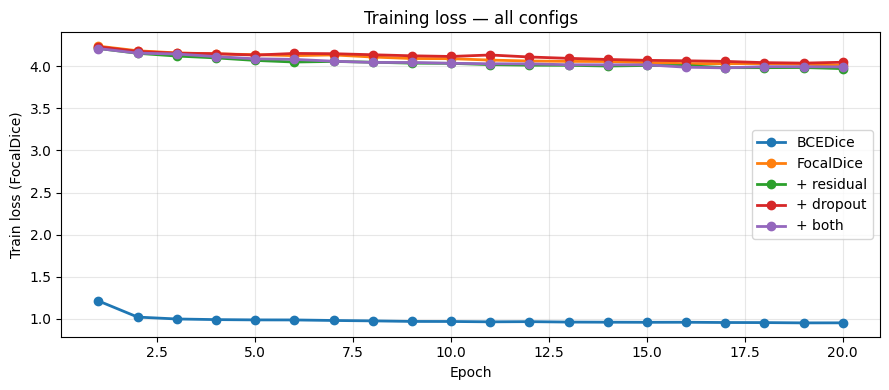

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, r in results.items():
    ax.plot(range(1, MAX_EPOCHS + 1), r["train_losses"], marker="o", label=name, linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss (FocalDice)")
ax.set_title("Training loss — all configs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / "results/comparison_train_loss.png", dpi=130)
plt.show()

### 5.2 Validation Metrics per Class

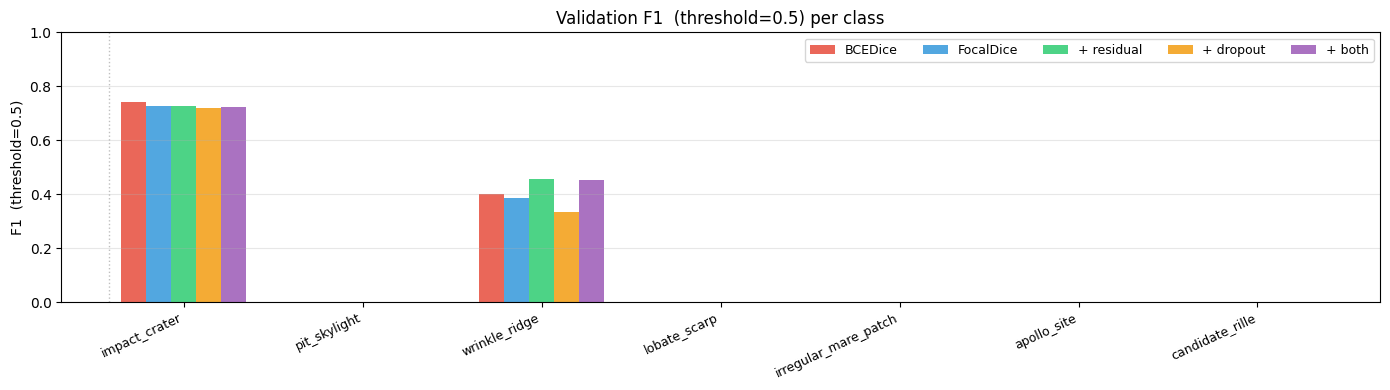

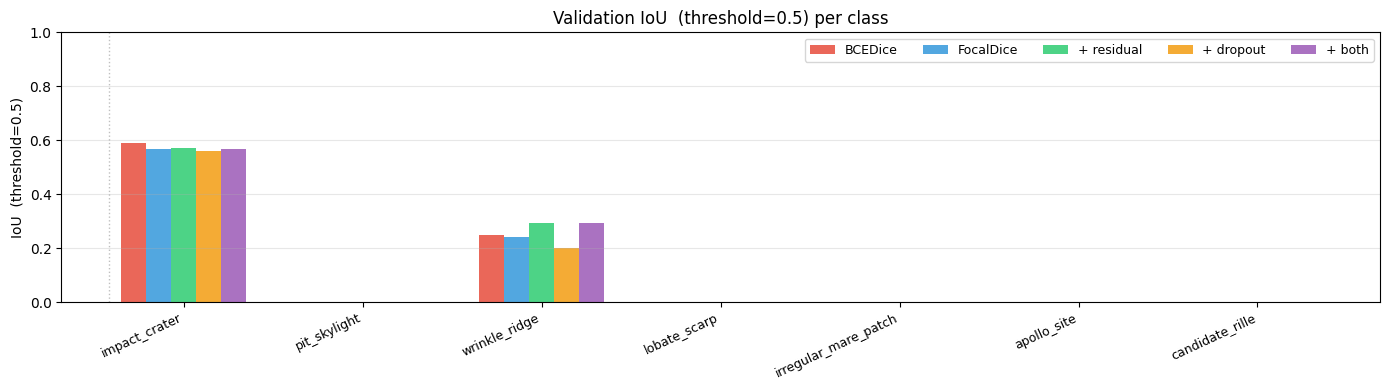

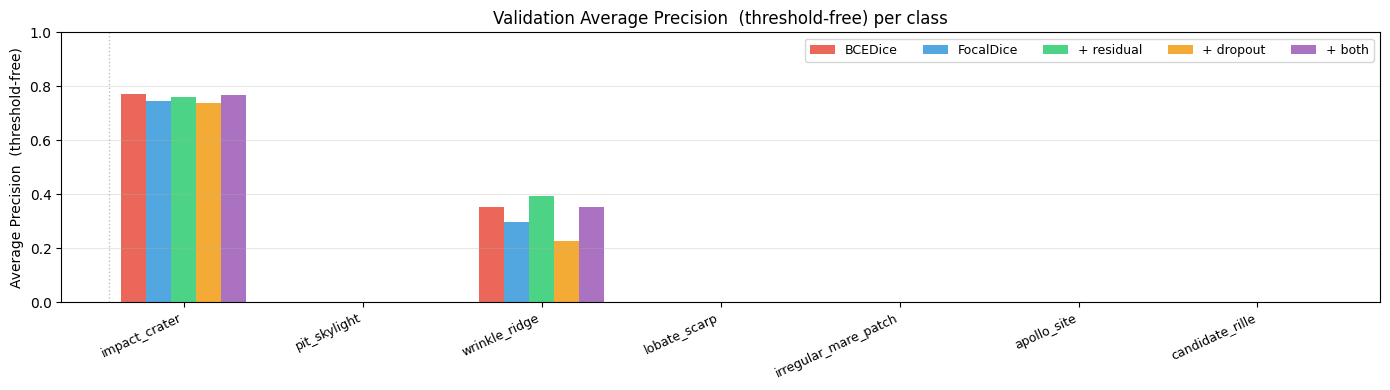

In [9]:
metric_rows = []
for name, r in results.items():
    if r["val_metrics"] is not None:
        df_m = r["val_metrics"].copy()
        df_m["config"] = name
        metric_rows.append(df_m.reset_index())

if not metric_rows:
    print("No validation metrics to plot.")
else:
    all_metrics = pd.concat(metric_rows, ignore_index=True)
    n_configs   = len(CONFIGS)
    colors      = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

    for metric in ("f1", "iou", "ap"):
        fig, ax = plt.subplots(figsize=(14, 4))
        width   = 0.14
        x       = np.arange(len(CLASS_NAMES))
        offsets = np.linspace(-(n_configs - 1) / 2,
                               (n_configs - 1) / 2, n_configs) * width

        for offset, color, (name, _) in zip(offsets, colors, CONFIGS.items()):
            vals = all_metrics[all_metrics["config"] == name].set_index("class")[metric]
            vals = [float(vals.get(c, 0)) for c in CLASS_NAMES]
            ax.bar(x + offset, vals, width, label=name, color=color, alpha=0.85)

        ax.axvline(x=0 - width * 3, color="grey", linestyle=":", linewidth=1, alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=9)
        label = {"f1": "F1  (threshold=0.5)", "iou": "IoU  (threshold=0.5)",
                 "ap": "Average Precision  (threshold-free)"}[metric]
        ax.set_ylabel(label)
        ax.set_title(f"Validation {label} per class")
        ax.legend(fontsize=9, ncol=n_configs)
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(BASE_DIR / f"results/comparison_val_{metric}.png", dpi=130)
        plt.show()

### 5.3 Summary Table

In [10]:
rows = []
for name, r in results.items():
    row = {
        "config":         name,
        "params":         f"{r['n_params']:,}",
        "final_loss":     f"{r['train_losses'][-1]:.4f}",
        "avg_epoch_s":    f"{np.mean(r['epoch_times']):.1f}s",
    }
    if r["val_metrics"] is not None:
        vm = r["val_metrics"].set_index("class")
        row["mean_F1"]  = f"{vm['f1'].mean():.4f}"
        row["mean_IoU"] = f"{vm['iou'].mean():.4f}"
        row["mean_AP"]  = f"{vm['ap'].mean():.4f}"
    else:
        row["mean_F1"] = row["mean_IoU"] = row["mean_AP"] = "—"
    rows.append(row)

summary = pd.DataFrame(rows).set_index("config")
print(summary.to_string())
print()
print("Best mean AP :", summary["mean_AP"].idxmax() if "mean_AP" in summary else "n/a")

               params final_loss avg_epoch_s mean_F1 mean_IoU mean_AP
config                                                               
BCEDice     1,927,207     0.9522      130.6s  0.1630   0.1198  0.1602
FocalDice   1,927,207     4.0094      137.2s  0.1590   0.1156  0.1491
+ residual  2,014,727     3.9716      160.0s  0.1690   0.1239  0.1649
+ dropout   1,927,207     4.0472      132.1s  0.1506   0.1090  0.1379
+ both      2,014,727     3.9922      158.1s  0.1679   0.1227  0.1597

Best mean AP : + residual


## 6. Base-Width Comparison

Fixes the best architecture (`+ both`: FocalDice + residual + dropout=0.3) and sweeps
`base_width` across three sizes. Parameter count scales as ~base_width², so wider
networks need more data and epochs to outperform a compact model on a label-sparse dataset.

| Config | `base_width` | Channels (encoder) | Params |
|---|---|---|---|
| `small` | 16 | 16 → 32 → 64 → 128 | ~120 k |
| `default` | 32 | 32 → 64 → 128 → 256 | ~480 k |
| `wide` | 64 | 64 → 128 → 256 → 512 | ~1.9 M |

In [11]:
BW_CONFIGS = OrderedDict([
    ("small  (bw=16)",   16),
    ("default(bw=32)",   32),
    ("wide   (bw=64)",   64),
])

print(f"{'Config':<22} {'base_width':>10} {'Params':>10}  (arch: FocalDice + residual + dropout)")
print("-" * 60)
for name, bw in BW_CONFIGS.items():
    m = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES),
                  base_width=bw, use_residual=True, dropout=0.3)
    print(f"{name:<22} {bw:>10} {m.count_parameters():>10,}")

print()

bw_results   = {}
bw_criterion = make_criterion("focal_dice")
_tiles_tag   = str(MAX_TILES) if MAX_TILES is not None else "all"
_ckpt_sfx    = f"_t{_tiles_tag}_e{MAX_EPOCHS}"

for name, bw in BW_CONFIGS.items():
    ckpt_path = CKPT_DIR / f"bw_{bw}{_ckpt_sfx}.pt"

    if ckpt_path.exists():
        print(f"\n[SKIP] {name} — loading from {ckpt_path.name}")
        saved = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
        bw_results[name] = saved["results"]
        continue

    print(f"\n{'='*50}\n  Training: {name}\n{'='*50}")
    model     = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES),
                          base_width=bw, use_residual=True, dropout=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=MAX_EPOCHS, eta_min=1e-5)
    trainer   = Trainer(model, optimizer, bw_criterion, device=DEVICE, scheduler=scheduler)

    train_losses, epoch_times = [], []
    for epoch in range(1, MAX_EPOCHS + 1):
        t0   = time.time()
        loss = trainer.train_one_epoch(train_loader)
        dt   = time.time() - t0
        train_losses.append(loss)
        epoch_times.append(dt)
        print(f"  epoch {epoch:>2}/{MAX_EPOCHS}  loss={loss:.4f}  "
              f"lr={trainer.current_lr():.2e}  {dt:.1f}s")

    entry = dict(
        train_losses = train_losses,
        epoch_times  = epoch_times,
        val_metrics  = trainer.evaluate(val_loader),
        base_width   = bw,
        n_params     = model.count_parameters(),
    )
    torch.save({"state_dict": model.state_dict(), "results": entry}, str(ckpt_path))
    print(f"  [SAVED] {ckpt_path.name}")
    bw_results[name] = entry

print("\nAll base-width configs trained.")

Config                 base_width     Params  (arch: FocalDice + residual + dropout)
------------------------------------------------------------
small  (bw=16)                 16    505,095
default(bw=32)                 32  2,014,727
wide   (bw=64)                 64  8,047,623


[SKIP] small  (bw=16) — loading from bw_16_t4000_e20.pt

[SKIP] default(bw=32) — loading from bw_32_t4000_e20.pt

[SKIP] wide   (bw=64) — loading from bw_64_t4000_e20.pt

All base-width configs trained.


In [12]:
print("Re-evaluating base-width configs…")
for name, bw in BW_CONFIGS.items():
    ckpt_path = CKPT_DIR / f"bw_{bw}{_ckpt_sfx}.pt"
    if not ckpt_path.exists():
        print(f"  {name}: no checkpoint, skipping")
        continue
    saved = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
    model = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES),
                      base_width=bw, use_residual=True, dropout=0.3).to(DEVICE)
    model.load_state_dict(saved["state_dict"])
    model.eval()
    with torch.no_grad():
        logits_list, targets_list = [], []
        for x, y in val_loader:
            logits_list.append(model(x.to(DEVICE)).cpu())
            targets_list.append(y.cpu())
    bw_results[name]["val_metrics"] = multilabel_metrics(
        torch.cat(logits_list), torch.cat(targets_list)
    )
    vm = bw_results[name]["val_metrics"].set_index("class")
    print(f"  {name:22s}  crater AP={vm.loc['impact_crater','ap']:.3f}  "
          f"ridge AP={vm.loc['wrinkle_ridge','ap']:.3f}")
print("Done.")

Re-evaluating base-width configs…
  small  (bw=16)          crater AP=0.757  ridge AP=0.339
  default(bw=32)          crater AP=0.764  ridge AP=0.356
  wide   (bw=64)          crater AP=0.757  ridge AP=0.375
Done.


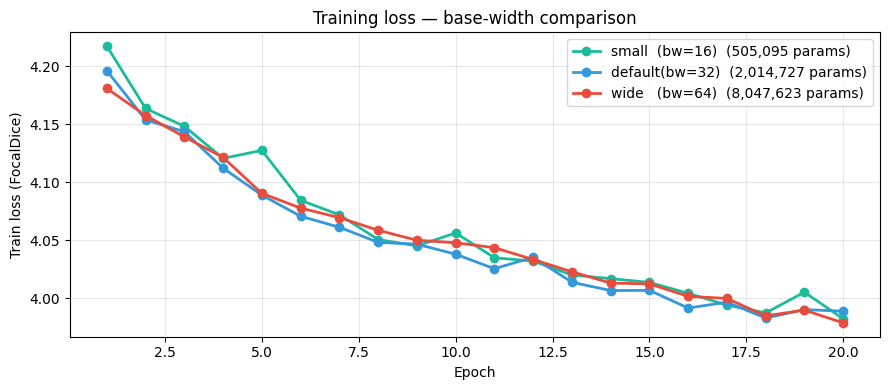

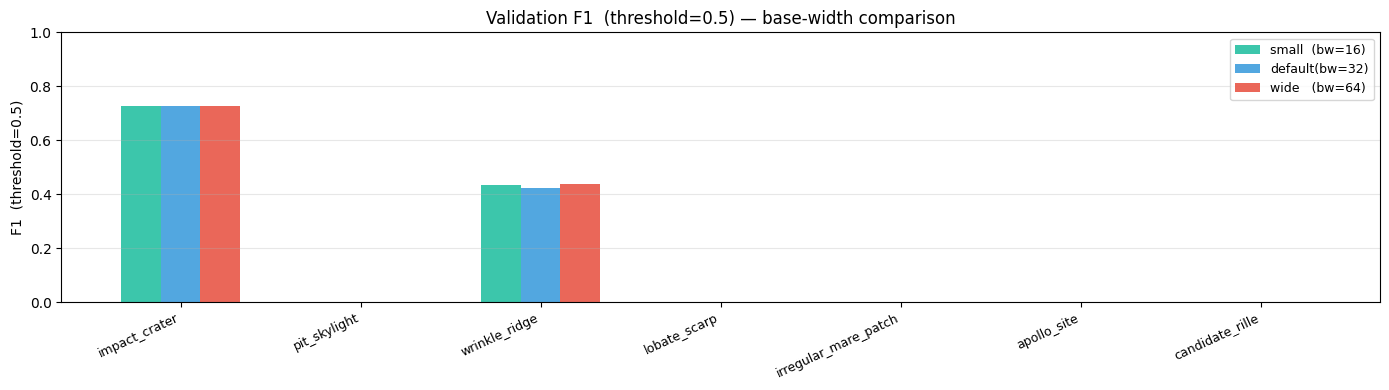

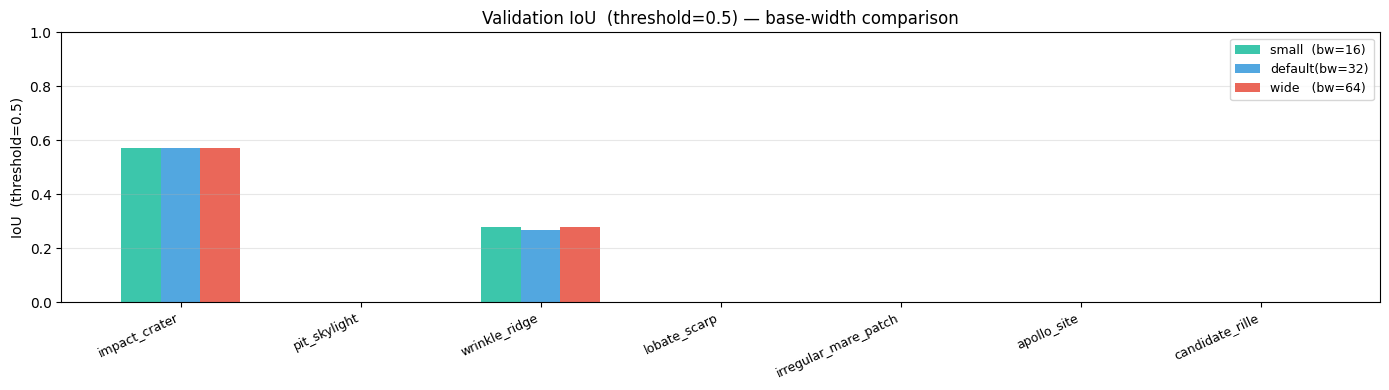

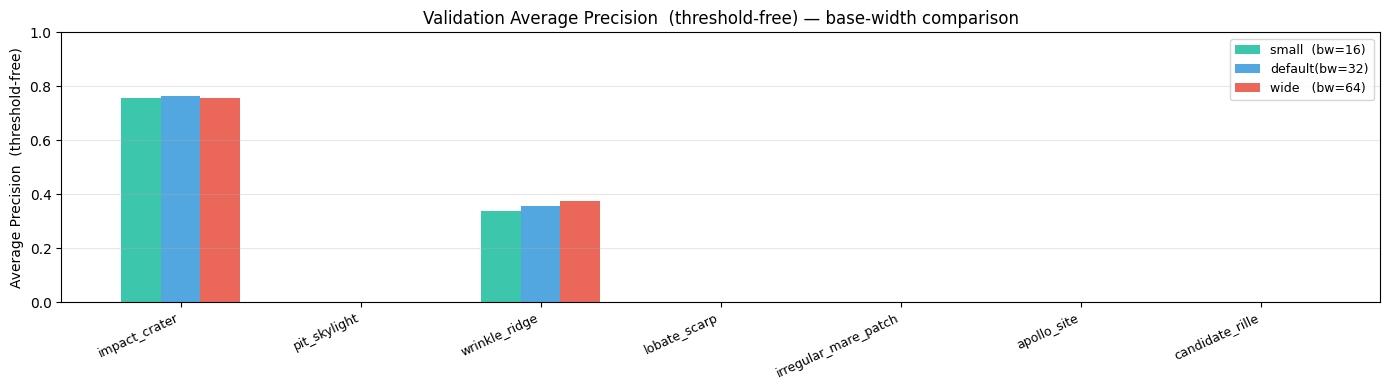

In [13]:
bw_colors = ["#1abc9c", "#3498db", "#e74c3c"]

fig, ax = plt.subplots(figsize=(9, 4))
for color, (name, r) in zip(bw_colors, bw_results.items()):
    ax.plot(range(1, MAX_EPOCHS + 1), r["train_losses"], marker="o",
            label=f"{name}  ({r['n_params']:,} params)", color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss (FocalDice)")
ax.set_title("Training loss — base-width comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / "results/bw_train_loss.png", dpi=130)
plt.show()

bw_metric_rows = []
for name, r in bw_results.items():
    if r["val_metrics"] is not None:
        df_m = r["val_metrics"].copy()
        df_m["config"] = name
        bw_metric_rows.append(df_m.reset_index())

if not bw_metric_rows:
    print("No validation metrics to plot.")
else:
    all_bw = pd.concat(bw_metric_rows, ignore_index=True)
    n_bw   = len(BW_CONFIGS)
    for metric in ("f1", "iou", "ap"):
        fig, ax = plt.subplots(figsize=(14, 4))
        width   = 0.22
        x       = np.arange(len(CLASS_NAMES))
        offsets = np.linspace(-(n_bw - 1) / 2, (n_bw - 1) / 2, n_bw) * width
        for offset, color, (name, _) in zip(offsets, bw_colors, BW_CONFIGS.items()):
            vals = all_bw[all_bw["config"] == name].set_index("class")[metric]
            vals = [float(vals.get(c, 0)) for c in CLASS_NAMES]
            ax.bar(x + offset, vals, width, label=name, color=color, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=9)
        label = {"f1": "F1  (threshold=0.5)", "iou": "IoU  (threshold=0.5)",
                 "ap": "Average Precision  (threshold-free)"}[metric]
        ax.set_ylabel(label)
        ax.set_title(f"Validation {label} — base-width comparison")
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(BASE_DIR / f"results/bw_val_{metric}.png", dpi=130)
        plt.show()

In [14]:
bw_rows = []
for name, r in bw_results.items():
    row = {"config": name, "bw": r["base_width"], "params": f"{r['n_params']:,}",
           "final_loss": f"{r['train_losses'][-1]:.4f}",
           "avg_epoch_s": f"{np.mean(r['epoch_times']):.1f}s"}
    if r["val_metrics"] is not None:
        vm = r["val_metrics"].set_index("class")
        row["mean_F1"]  = f"{vm['f1'].mean():.4f}"
        row["mean_IoU"] = f"{vm['iou'].mean():.4f}"
        row["mean_AP"]  = f"{vm['ap'].mean():.4f}"
    else:
        row["mean_F1"] = row["mean_IoU"] = row["mean_AP"] = "—"
    bw_rows.append(row)

bw_summary = pd.DataFrame(bw_rows).set_index("config")
print(bw_summary.to_string())
print()
print("Best mean AP:", bw_summary["mean_AP"].idxmax() if "mean_AP" in bw_summary else "n/a")

                bw     params final_loss avg_epoch_s mean_F1 mean_IoU mean_AP
config                                                                       
small  (bw=16)  16    505,095     3.9821       71.3s  0.1659   0.1213  0.1567
default(bw=32)  32  2,014,727     3.9886      157.8s  0.1642   0.1199  0.1602
wide   (bw=64)  64  8,047,623     3.9786      461.6s  0.1660   0.1213  0.1618

Best mean AP: wide   (bw=64)


## 7. Data Augmentation Comparison

Fixes the best architecture (`+ both`: FocalDice + residual + dropout=0.3, base_width=32)
and isolates the effect of augmentation.

Two training loaders are built from the **same cached tiles and the same train/val split**;
the only difference is whether the augmentation pipeline is applied.

| Config | h-flip | v-flip | 90°/180°/270° rot |
|---|---|---|---|
| `no augmentation` | ✗ | ✗ | ✗ |
| `+ augmentation`  | ✓ | ✓ | ✓ |

In [15]:
AUG_CONFIGS = OrderedDict([
    ("no augmentation", False),
    ("+ augmentation",  True),
])

aug_results   = {}
aug_criterion = make_criterion("focal_dice")
_tiles_tag    = str(MAX_TILES) if MAX_TILES is not None else "all"
_ckpt_sfx     = f"_t{_tiles_tag}_e{MAX_EPOCHS}"

for name, do_aug in AUG_CONFIGS.items():
    ckpt_path = CKPT_DIR / f"aug_{'on' if do_aug else 'off'}{_ckpt_sfx}.pt"

    if ckpt_path.exists():
        print(f"\n[SKIP] {name} — loading from {ckpt_path.name}")
        saved = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
        aug_results[name] = saved["results"]
        continue

    print(f"\n{'='*50}\n  Training: {name}\n{'='*50}")

    ds      = _TileDataset(_tiles, train_idx, augment=do_aug)
    loader  = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    model     = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES),
                          base_width=32, use_residual=True, dropout=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=MAX_EPOCHS, eta_min=1e-5)
    trainer   = Trainer(model, optimizer, aug_criterion, device=DEVICE, scheduler=scheduler)

    train_losses, epoch_times = [], []
    for epoch in range(1, MAX_EPOCHS + 1):
        t0   = time.time()
        loss = trainer.train_one_epoch(loader)
        dt   = time.time() - t0
        train_losses.append(loss)
        epoch_times.append(dt)
        print(f"  epoch {epoch:>2}/{MAX_EPOCHS}  loss={loss:.4f}  "
              f"lr={trainer.current_lr():.2e}  {dt:.1f}s")

    entry = dict(
        train_losses = train_losses,
        epoch_times  = epoch_times,
        val_metrics  = trainer.evaluate(val_loader),
        n_params     = model.count_parameters(),
    )
    torch.save({"state_dict": model.state_dict(), "results": entry}, str(ckpt_path))
    print(f"  [SAVED] {ckpt_path.name}")
    aug_results[name] = entry

print("\nAugmentation comparison done.")


[SKIP] no augmentation — loading from aug_off_t4000_e20.pt

[SKIP] + augmentation — loading from aug_on_t4000_e20.pt

Augmentation comparison done.


In [16]:
print("Re-evaluating augmentation configs…")
for name, do_aug in AUG_CONFIGS.items():
    ckpt_path = CKPT_DIR / f"aug_{'on' if do_aug else 'off'}{_ckpt_sfx}.pt"
    if not ckpt_path.exists():
        print(f"  {name}: no checkpoint, skipping")
        continue
    saved = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
    model = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES),
                      base_width=32, use_residual=True, dropout=0.3).to(DEVICE)
    model.load_state_dict(saved["state_dict"])
    model.eval()
    with torch.no_grad():
        logits_list, targets_list = [], []
        for x, y in val_loader:
            logits_list.append(model(x.to(DEVICE)).cpu())
            targets_list.append(y.cpu())
    aug_results[name]["val_metrics"] = multilabel_metrics(
        torch.cat(logits_list), torch.cat(targets_list)
    )
    vm = aug_results[name]["val_metrics"].set_index("class")
    print(f"  {name:20s}  crater AP={vm.loc['impact_crater','ap']:.3f}  "
          f"ridge AP={vm.loc['wrinkle_ridge','ap']:.3f}")
print("Done.")

Re-evaluating augmentation configs…
  no augmentation       crater AP=0.774  ridge AP=0.613
  + augmentation        crater AP=0.766  ridge AP=0.354
Done.


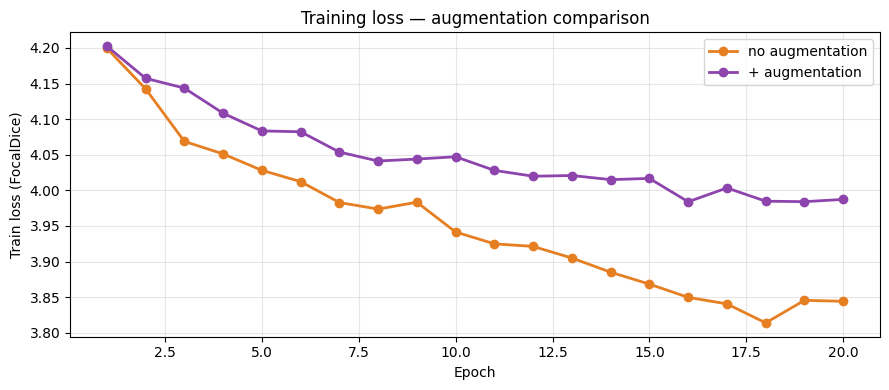

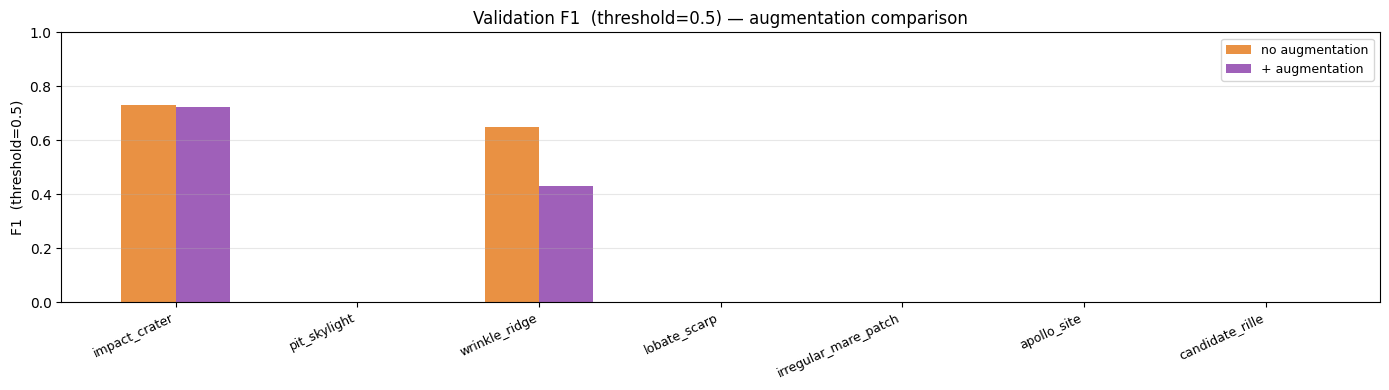

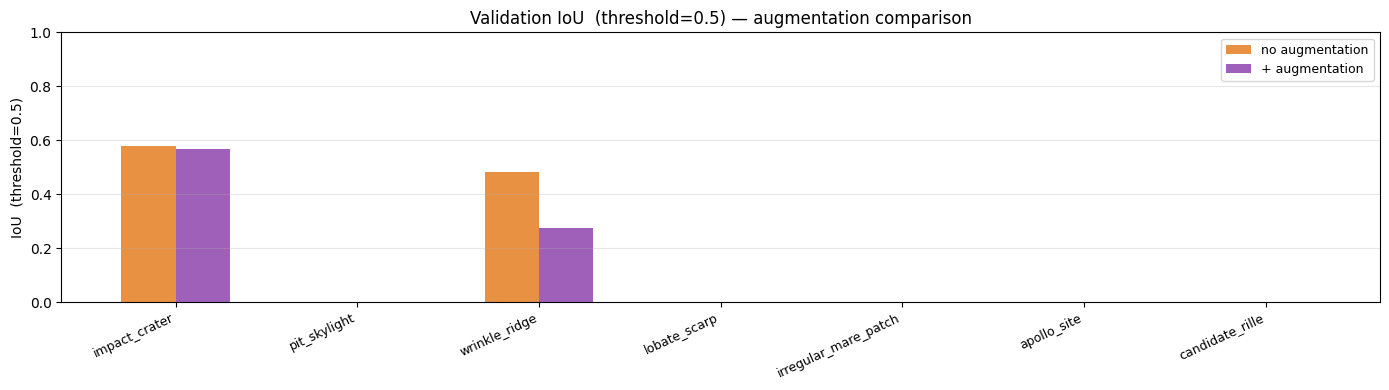

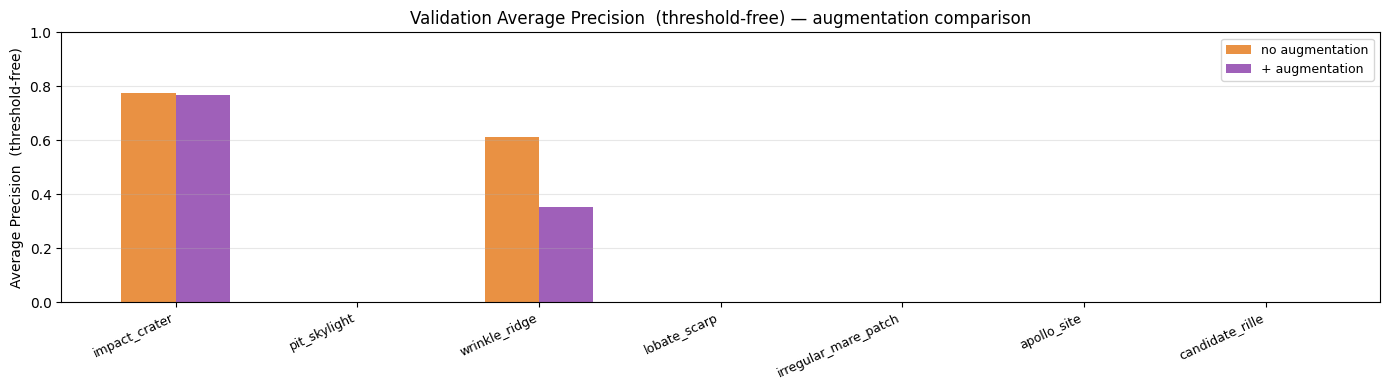

                final_loss avg_epoch_s mean_F1 mean_IoU mean_AP
config                                                         
no augmentation     3.8443      159.7s  0.1974   0.1512  0.1982
+ augmentation      3.9873      207.7s  0.1648   0.1201  0.1601

Best mean AP: no augmentation


In [17]:
aug_colors = ["#e67e22", "#8e44ad"]

fig, ax = plt.subplots(figsize=(9, 4))
for color, (name, r) in zip(aug_colors, aug_results.items()):
    ax.plot(range(1, MAX_EPOCHS + 1), r["train_losses"], marker="o",
            label=name, color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss (FocalDice)")
ax.set_title("Training loss — augmentation comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / "results/aug_train_loss.png", dpi=130)
plt.show()

aug_metric_rows = []
for name, r in aug_results.items():
    if r["val_metrics"] is not None:
        df_m = r["val_metrics"].copy()
        df_m["config"] = name
        aug_metric_rows.append(df_m.reset_index())

if not aug_metric_rows:
    print("No validation metrics to plot.")
else:
    all_aug = pd.concat(aug_metric_rows, ignore_index=True)
    n_aug   = len(AUG_CONFIGS)
    for metric in ("f1", "iou", "ap"):
        fig, ax = plt.subplots(figsize=(14, 4))
        width   = 0.30
        x       = np.arange(len(CLASS_NAMES))
        offsets = np.linspace(-(n_aug - 1) / 2, (n_aug - 1) / 2, n_aug) * width
        for offset, color, (name, _) in zip(offsets, aug_colors, AUG_CONFIGS.items()):
            vals = all_aug[all_aug["config"] == name].set_index("class")[metric]
            vals = [float(vals.get(c, 0)) for c in CLASS_NAMES]
            ax.bar(x + offset, vals, width, label=name, color=color, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=9)
        label = {"f1": "F1  (threshold=0.5)", "iou": "IoU  (threshold=0.5)",
                 "ap": "Average Precision  (threshold-free)"}[metric]
        ax.set_ylabel(label)
        ax.set_title(f"Validation {label} — augmentation comparison")
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(BASE_DIR / f"results/aug_val_{metric}.png", dpi=130)
        plt.show()

aug_rows = []
for name, r in aug_results.items():
    row = {"config": name, "final_loss": f"{r['train_losses'][-1]:.4f}",
           "avg_epoch_s": f"{np.mean(r['epoch_times']):.1f}s"}
    if r["val_metrics"] is not None:
        vm = r["val_metrics"].set_index("class")
        row["mean_F1"]  = f"{vm['f1'].mean():.4f}"
        row["mean_IoU"] = f"{vm['iou'].mean():.4f}"
        row["mean_AP"]  = f"{vm['ap'].mean():.4f}"
    else:
        row["mean_F1"] = row["mean_IoU"] = row["mean_AP"] = "—"
    aug_rows.append(row)

aug_summary = pd.DataFrame(aug_rows).set_index("config")
print(aug_summary.to_string())
print()
print("Best mean AP:", aug_summary["mean_AP"].idxmax() if "mean_AP" in aug_summary else "n/a")